# HW3

Быкова Амина

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [ ]:
df = pd.read_csv("ab_testing.csv")

df.head()

,user_id,group,visit_date,page_version,time_on_page,clicked_CTA,converted,device_type,traffic_source
0,1,A,2024-01-17,Original,35,0,0,Tablet,Paid
1,2,B,2024-01-17,Optimized,24,1,0,Desktop,Social Media
2,3,B,2024-01-22,Optimized,11,1,0,Desktop,Organic
3,4,B,2024-01-20,Optimized,67,1,0,Desktop,Organic
4,5,A,2024-01-22,Original,38,1,0,Mobile,Paid


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         85000 non-null  int64 
 1   group           85000 non-null  object
 2   visit_date      85000 non-null  object
 3   page_version    85000 non-null  object
 4   time_on_page    85000 non-null  int64 
 5   clicked_CTA     85000 non-null  int64 
 6   converted       85000 non-null  int64 
 7   device_type     85000 non-null  object
 8   traffic_source  85000 non-null  object
dtypes: int64(4), object(5)
memory usage: 5.8+ MB


## 1. Определение метрик

- **Основная:** CTR = clicked_CTA (это бинарная метрика > будем сравнивать доли)

- **Дополнительная:** time_on_page (непонятно, в какую сторону хорошо)

- **Safety:** конверсия — converted (если падает — нельзя выкатывать)

## 2. Проверка корректности запуска A/B теста
### Размеры групп

In [ ]:
df['group'].value_counts(normalize=True)

,proportion
group,
B,0.501165
A,0.498835


In [ ]:
print(1 - df['group'].value_counts()['A'] / df['group'].value_counts()['B'])

0.004647996431841106


Разница меньше, чем в 1%, значит, группы примерно одинаковые по размеру (дисбаланса нет).

Проверяем, встречается ли один пользователь в обеих группах (проверка независимости теста):

In [ ]:
users_A = set(df[df['group'] == 'A']['user_id'])
users_B = set(df[df['group'] == 'B']['user_id'])

len(users_A.intersection(users_B))

0

Пересечений между пользователями в группах нет, значит, выборки независимые.

### Проверка уникальности пользователей

In [ ]:
df['user_id'].nunique(), len(df)

(85000, 85000)

Числа равные, значит, дубликатов нет.
### Проверка null значений

In [ ]:
df.isnull().sum()

,0
user_id,0
group,0
visit_date,0
page_version,0
time_on_page,0
clicked_CTA,0
converted,0
device_type,0
traffic_source,0


Null-значений нет.
### Проверка неестественных значений

In [ ]:
df.describe()

,user_id,time_on_page,clicked_CTA,converted
count,85000.000000,85000.000000,85000.000000,85000.000000
mean,42500.500000,52.542365,0.400918,0.065941
std,24537.530778,14.801910,0.490087,0.248181
min,1.000000,10.000000,0.000000,0.000000
25%,21250.750000,42.000000,0.000000,0.000000
50%,42500.500000,51.000000,0.000000,0.000000
75%,63750.250000,62.000000,1.000000,0.000000
max,85000.000000,118.000000,1.000000,1.000000


Аномальных значений тоже нет, времени на странице с отрицательными или слишком большими значениями нет.

### Проверка соответствия group и page_version

In [ ]:
pd.crosstab(df['group'], df['page_version'])

page_version,Optimized,Original
group,,
A,0,42401
B,42599,0


Разметка корректная.

### Проверка рандомизации по сегментам

При корректной рандомизации типы устройств и источники трафика должны быть распределены примерно одинаково между группами A и B. Проверяем с помощью хи-квадрат теста независимости (α = 0.05).
- H0: Распределение по категориям (device_type / traffic_source) не зависит от группы теста (рандомизация корректна)
- H1: Распределение по категориям зависит от группы теста (рандомизация нарушена)

#### Устройство (device_type)

In [ ]:
pd.crosstab(df['group'], df['device_type'], normalize='index')

device_type,Desktop,Mobile,Tablet
group,,,
A,0.597509,0.303318,0.099172
B,0.598136,0.302308,0.099556


In [ ]:
stats.chi2_contingency(pd.crosstab(df['group'], df['device_type']))

Chi2ContingencyResult(statistic=np.float64(0.11720640273124024), pvalue=np.float64(0.9430809081397317), dof=2, expected_freq=array([[25348.31547059, 12839.52163529,  4213.16289412],
       [25466.68452941, 12899.47836471,  4232.83710588]]))

p-value = 0.94. Различий нет, распределение пользователей по устройствам одинаковое.

#### Источник трафика (traffic_source)

In [ ]:
pd.crosstab(df['group'], df['traffic_source'], normalize='index')

traffic_source,Organic,Paid,Referral,Social Media
group,,,,
A,0.402137,0.299191,0.099054,0.199618
B,0.395103,0.304092,0.100378,0.200427


In [ ]:
stats.chi2_contingency(pd.crosstab(df['group'], df['traffic_source']))

Chi2ContingencyResult(statistic=np.float64(4.77207078795432), pvalue=np.float64(0.18926856433196965), dof=3, expected_freq=array([[16901.53743529, 12790.13694118,  4228.12795294,  8481.19767059],
       [16980.46256471, 12849.86305882,  4247.87204706,  8520.80232941]]))

p = 0.19. Различий нет, распределение по каналам одинаковое

### Проверка по времени

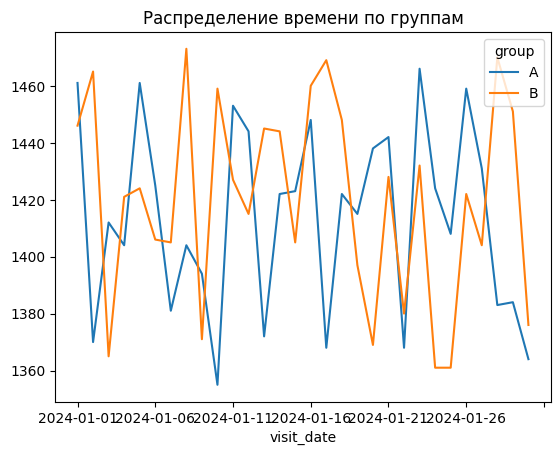

In [ ]:
df.groupby(['visit_date', 'group']).size().unstack().plot()
plt.title("Распределение времени по группам")
plt.show()

Тест запущен корректно.

## 3. Визуализации
### CTR (для бизнеса)

In [ ]:
ctr = df.groupby('group')['clicked_CTA'].mean()
ctr

,clicked_CTA
group,
A,0.302611
B,0.498768


+19.6 процентных пункта

≈ +65% относительный рост — это очень большой эффект

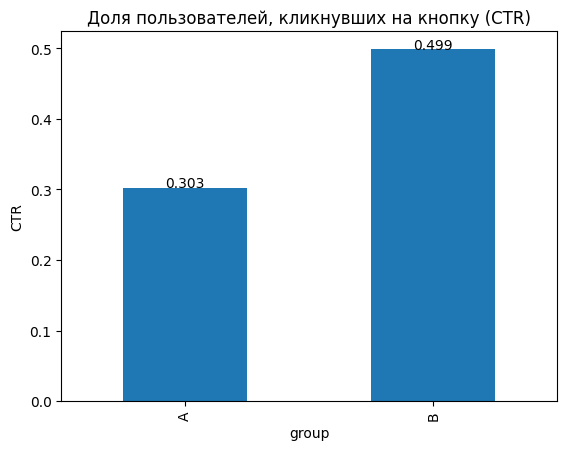

In [ ]:
ctr.plot(kind='bar')
plt.title("Доля пользователей, кликнувших на кнопку (CTR)")
plt.ylabel("CTR")

for i, v in enumerate(ctr):
    plt.text(i, v, round(v,3), ha='center')

plt.show()

### Конверсия (для бизнеса)

In [ ]:
cr = df.groupby('group')['converted'].mean()
cr

,converted
group,
A,0.030495
B,0.101223


+7.07 п.п.

≈ рост более чем в 3 раза — неожиданно сильный эффект

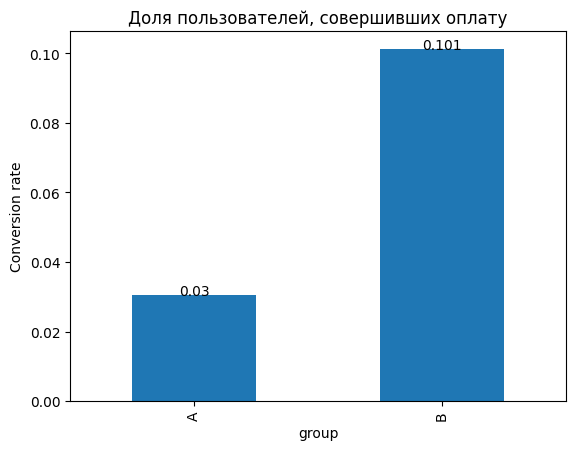

In [ ]:
cr.plot(kind='bar')
plt.title("Доля пользователей, совершивших оплату")
plt.ylabel("Conversion rate")

for i, v in enumerate(cr):
    plt.text(i, v, round(v,3), ha='center')

plt.show()

### Время на странице (для бизнеса)

In [ ]:
time_stats = df.groupby('group')['time_on_page'].agg(['mean','median'])
time_stats

,mean,median
group,,
A,45.014410,45.0
B,60.035329,60.0


+15 секунд (~+33%)

Пользователи проводят значительно больше времени на странице.

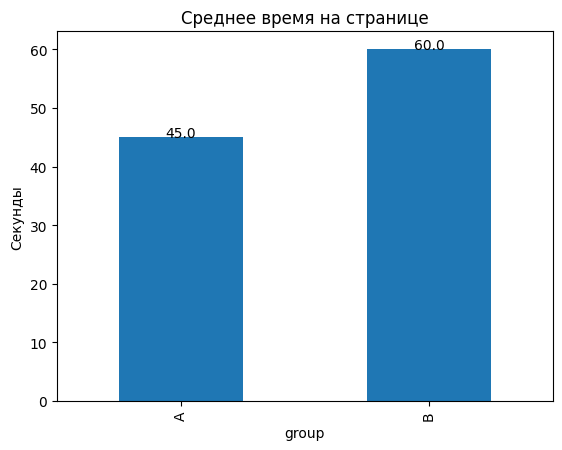

In [ ]:
time_stats['mean'].plot(kind='bar')
plt.title("Среднее время на странице")
plt.ylabel("Секунды")

for i, v in enumerate(time_stats['mean']):
    plt.text(i, v, round(v,1), ha='center')

plt.show()

### Распределение времени (для аналитиков)

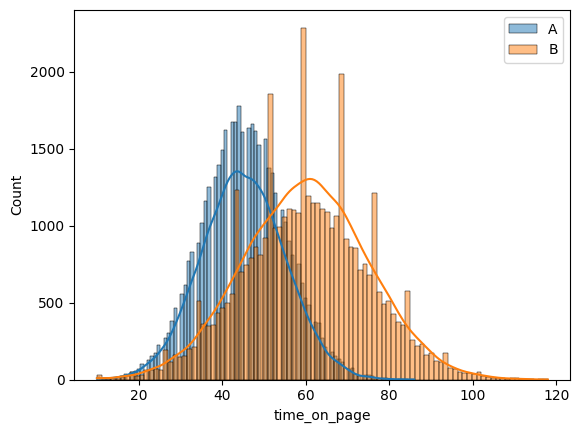

In [ ]:
sns.histplot(df[df['group']=='A']['time_on_page'], kde=True, label='A')
sns.histplot(df[df['group']=='B']['time_on_page'], kde=True, label='B')
plt.legend()
plt.show()

## 4. Статистический анализ

### Метрика CTR

**Выбор теста:** Z-тест (или chi-square)

**Обоснование:**
- CTR — это доля (бинарная переменная: кликнул/не кликнул)

- Выборки независимые (каждый пользователь только в одной группе)

- Размер выборки большой (n ≈ 42500 в каждой группе), следовательно, достаточно наблюдений для корректного применения z-теста
- Z-тест для пропорций — стандартный параметрический тест для сравнения двух пропорций

**Гипотезы:**

- H0: CTR_A = CTR_B (доли кликов в группах одинаковы, эффекта нет)
- H1: CTR_A ≠ CTR_B (доли кликов различаются, эффект есть)

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

clicks = df.groupby('group')['clicked_CTA'].sum()
nobs = df.groupby('group')['clicked_CTA'].count()

stat, p_value = proportions_ztest(
    count=[clicks['B'], clicks['A']],
    nobs=[nobs['B'], nobs['A']],
    alternative='larger'
)

print(f'{stat}, {p_value}')

58.34595910000897, 0.0


H0 отвергается, CTR в группе B значимо выше.

### Конверсия (converted)
**Выбор теста:** Z-тест для пропорций

**Обоснование:**
- Конверсия — тоже доля (бинарная переменная: купил/не купил)
- Выборки независимые, размер большой
- Это safety-метрика: мы хотим убедиться, что она не упала

**Гипотезы:**
- H0: CR_A = CR_B (доли конверсий в группах одинаковы)
- H1: CR_A ≠ CR_B (доли конверсий различаются)

In [ ]:
conv = df.groupby('group')['converted'].sum()
nobs = df.groupby('group')['converted'].count()

stat_conv, p_conv = proportions_ztest(
    count=[conv['B'], conv['A']],
    nobs=[nobs['B'], nobs['A']]
)

print(f'{stat_conv}, {p_conv}')

41.54388340132069, 0.0


H0 отвергается, конверсия в B значимо выше.

### Время на странице (time_on_page)
Предварительный шаг — проверка нормальности распределения

Логика выбора теста:
- Если распределение нормальное, то параметрический t-тест (более мощный)
- Если распределение ненормальное, то непараметрический тест Манна-Уитни (не требует нормальности)

Для проверки нормальности распределения был использован **тест Шапиро–Уилка**. Однако при больших размерах выборки данный тест (как и тест Колмогорова-Смирнова) становится избыточно чувствительным и может выявлять статистически значимые, но практически несущественные отклонения от нормальности.

Поэтому дополнительно анализировались визуальные распределения, а для дальнейшего анализа был выбран непараметрический тест Манна–Уитни, не требующий предположения о нормальности.

Тест на нормальность:
- H0: распределение нормально
- H1: распределение НЕ нормально

In [ ]:
group_A = df[df['group']=='A']['time_on_page']
stats.shapiro(group_A.sample(5000))

ShapiroResult(statistic=np.float64(0.9987454291614721), pvalue=np.float64(0.0006625765039554042))

In [ ]:
group_B = df[df['group']=='B']['time_on_page']
stats.shapiro(group_B.sample(5000))

ShapiroResult(statistic=np.float64(0.9992808804791247), pvalue=np.float64(0.04003856920862257))

p-value < 0.05 для обеих групп, значит, распределение не является нормальным, выбираем непараметрический тест.

**Тест Манна-Уитни**

Гипотезы:
- H0: Распределения time_on_page в группах A и B одинаковы (сдвига нет)
- H1: Распределения time_on_page в группах A и B различаются (сдвиг есть)

In [ ]:
stats.mannwhitneyu(group_A, group_B)

MannwhitneyuResult(statistic=np.float64(365358067.0), pvalue=np.float64(0.0))

Различие значимо, время действительно увеличилось.

## 5. Анализ по разрезам

### CTR по device

In [ ]:
device_ctr = df.groupby(['device_type','group'])['clicked_CTA'].mean().unstack()
device_ctr

group,A,B
device_type,,
Desktop,0.306414,0.496978
Mobile,0.297489,0.504349
Tablet,0.295363,0.492573


Рост во всех сегментах

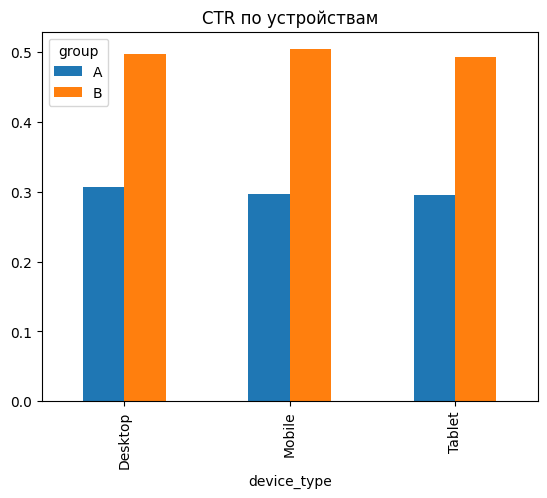

In [ ]:
device_ctr.plot(kind='bar')
plt.title("CTR по устройствам")
plt.show()

#### Cтат тесты по сегментам

In [ ]:
for device in df['device_type'].unique():
    sub = df[df['device_type']==device]

    success = sub.groupby('group')['clicked_CTA'].sum()
    nobs = sub.groupby('group')['clicked_CTA'].count()

    print(device)
    print(proportions_ztest(success, nobs))

Tablet
(np.float64(-18.542194263488135), np.float64(9.429472373734223e-77))
Desktop
(np.float64(-43.807357326786224), np.float64(0.0))
Mobile
(np.float64(-33.85781770177809), np.float64(2.784635160465363e-251))


p-value во всех случаях < 0.05 (эффект устойчив)

### CTR по traffic

In [ ]:
traffic_ctr = df.groupby(['traffic_source','group'])['clicked_CTA'].mean().unstack()
traffic_ctr

group,A,B
traffic_source,,
Organic,0.304088,0.500862
Paid,0.301750,0.501853
Referral,0.305476,0.497428
Social Media,0.299504,0.490630


Эффект одинаковый по всем каналам, нет перекоса, это сильный признак надёжности.

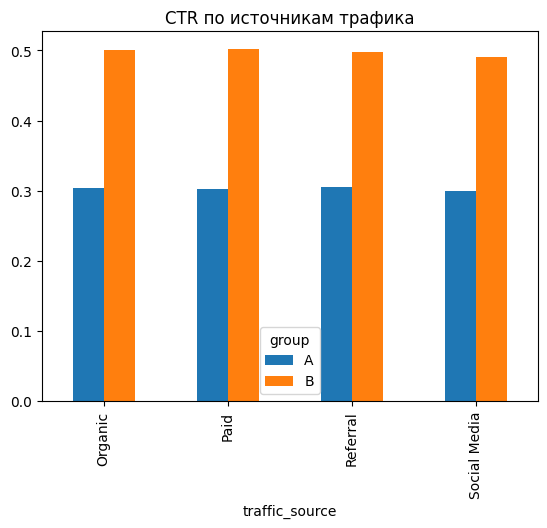

In [ ]:
traffic_ctr.plot(kind='bar')
plt.title("CTR по источникам трафика")
plt.show()

### Итоговый вывод
Редизайн страницы привёл к значительному увеличению CTR, значительному росту конверсии и увеличению времени на странице. Все эффекты статистически значимы и устойчивы.

## 6. Динамика по времени

### CTR во времени

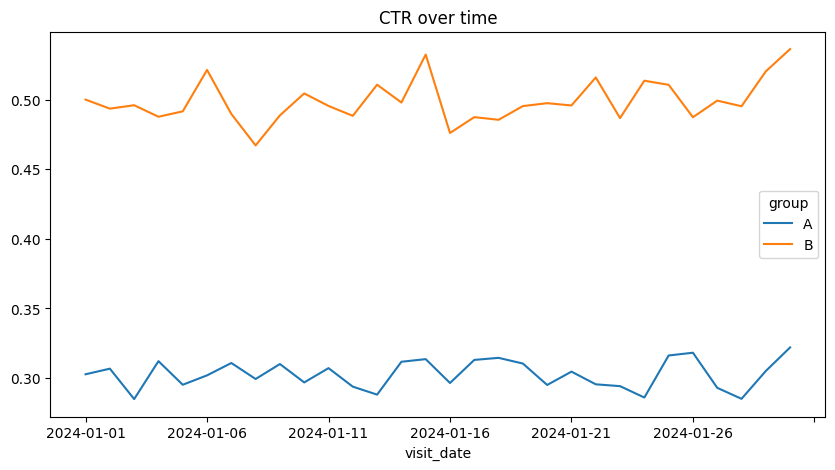

In [ ]:
daily_ctr = df.groupby(['visit_date','group'])['clicked_CTA'].mean().unstack()

daily_ctr.plot(figsize=(10,5))
plt.title("CTR over time")
plt.show()

### Конверсия во времени

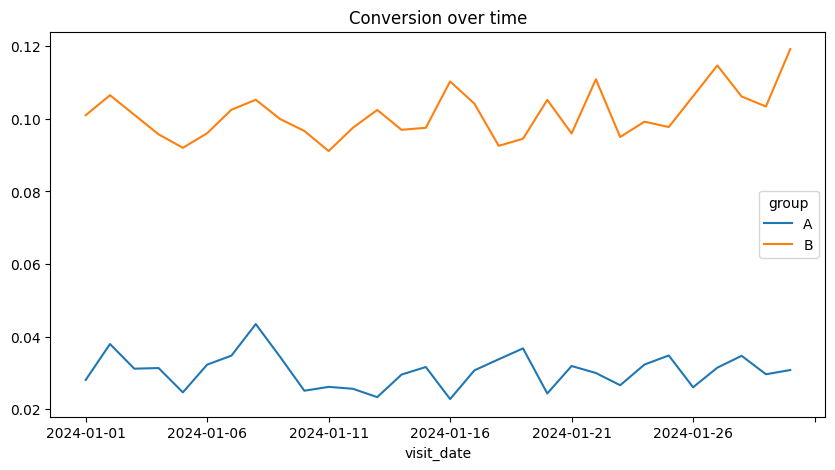

In [ ]:
daily_cr = df.groupby(['visit_date','group'])['converted'].mean().unstack()

daily_cr.plot(figsize=(10,5))
plt.title("Conversion over time")
plt.show()

### Время на странице во времени

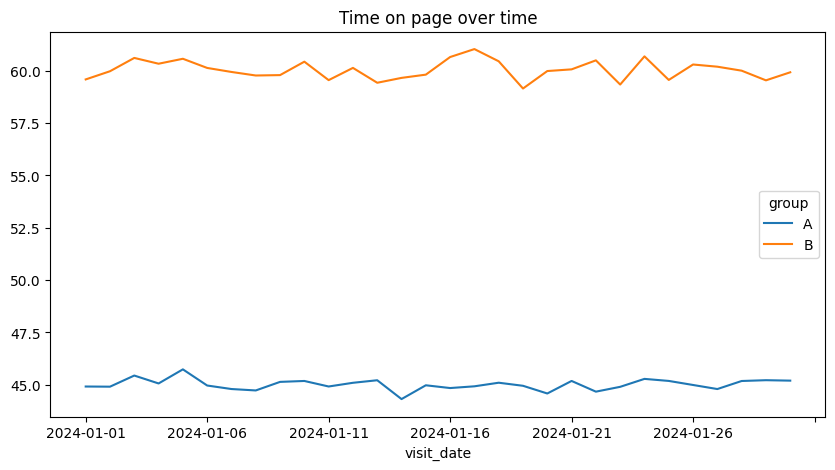

In [ ]:
daily_time = df.groupby(['visit_date','group'])['time_on_page'].mean().unstack()

daily_time.plot(figsize=(10,5))
plt.title("Time on page over time")
plt.show()

Динамика метрик по времени показывает стабильный и устойчивый эффект: значения в группе B на протяжении всего периода остаются выше группы A. Это говорит о том, что результат не является случайным или временным и сохраняется на всём протяжении эксперимента.

## 6. Выводы для бизнеса

#### **Что изменили:**
Мы полностью переработали страницу начала бесплатного пробного периода (дизайн, структура, визуальные элементы и расположение блоков).

#### **Что произошло:**

Это привело к следующим изменениям:

- доля пользователей, нажимающих кнопку начала пробного периода, выросла **с 30% до 50%**
- доля пользователей, которые в итоге оплачивают подписку, выросла **с 3% до 10%**
- пользователи стали проводить на странице на **33% больше времени**

#### **Насколько уверены:**

- эффект статистически устойчив
- наблюдается во всех сегментах пользователей (устройства и источники трафика)
- не зависит от канала привлечения

Результат можно считать надёжным.

#### **Что это даёт бизнесу:**
- значительно больше пользователей начинают пробный период
- существенно больше пользователей доходят до оплаты
- увеличение выручки с того же объёма трафика

#### **Что делать дальше:**

Рекомендуется раскатать новую версию страницы на всех пользователей.

**Риски:** возможен эффект новизны (новый дизайн временно лучше работает).

## 7. Рефлексия использования ИИ

ИИ использовался для генерации кода, с помощью которого я делала выводы, а ещё для того чтобы добавить среднее значение на графики. Также я уточняла, правильна ли моя логика решений при выборе тех или иных тестов.